In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

load data training dan testing

In [19]:
train = pd.read_csv("data/processed/train_set.csv")
test  = pd.read_csv("data/processed/test_set.csv")

with open("data/models/fitur_names.json") as f:
    meta = json.load(f)

FITUR  = meta["fitur"]
TARGET = meta["target"]

X_train = train[FITUR].values
y_train = train[TARGET].values
X_test  = test[FITUR].values
y_test  = test[TARGET].values

print(f"X_train: {X_train.shape} | y_train distribusi: {pd.Series(y_train).value_counts().to_dict()}")
print(f"X_test : {X_test.shape}  | y_test  distribusi: {pd.Series(y_test).value_counts().to_dict()}")

X_train: (30686, 19) | y_train distribusi: {0: 29413, 1: 1273}
X_test : (7672, 19)  | y_test  distribusi: {0: 7354, 1: 318}


handle class imbalance dengan smote

In [20]:
print(f"\nsebelum smote")
print(f"  train - normal : {sum(y_train==0):,}")
print(f"  train - anomali: {sum(y_train==1):,}")
print(f"  test  - normal : {sum(y_test==0):,}")
print(f"  test  - anomali: {sum(y_test==1):,}")

n_anomali_train = sum(y_train == 1)
k_smote = min(5, n_anomali_train - 1)
print(f"\njumlah sampel anomali di train: {n_anomali_train}")
print(f"k_neighbors smote yang dipakai : {k_smote}")

smote = SMOTE(random_state=42, k_neighbors=k_smote)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nsetelah smote:")
print(f"  train - normal : {sum(y_train_res==0):,}")
print(f"  train - anomali: {sum(y_train_res==1):,}")
print(f"  rasio normal:anomali = {sum(y_train_res==0)/sum(y_train_res==1):.2f}:1")


sebelum smote
  train - normal : 29,413
  train - anomali: 1,273
  test  - normal : 7,354
  test  - anomali: 318

jumlah sampel anomali di train: 1273
k_neighbors smote yang dipakai : 5

setelah smote:
  train - normal : 29,413
  train - anomali: 29,413
  rasio normal:anomali = 1.00:1


cari nilai k optimal untuk kNN

In [21]:
k_values = list(range(1, 22, 2))  # 1, 3, 5, 7, ... 21
k_scores = {}

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn_temp.fit(X_train_res, y_train_res)
    y_pred_temp = knn_temp.predict(X_test)
    score = f1_score(y_test, y_pred_temp, zero_division=0)
    k_scores[k] = round(score, 4)
    print(f"  k={k:2d} → f1_score={score:.4f}")

best_k = max(k_scores, key=k_scores.get)
print(f"\nnilai k terbaik: {best_k} (f1_score={k_scores[best_k]:.4f})")

  k= 1 → f1_score=0.2130
  k= 3 → f1_score=0.6083
  k= 5 → f1_score=0.6614
  k= 7 → f1_score=0.6644
  k= 9 → f1_score=0.6600
  k=11 → f1_score=0.6507
  k=13 → f1_score=0.6465
  k=15 → f1_score=0.6416
  k=17 → f1_score=0.6348
  k=19 → f1_score=0.6344
  k=21 → f1_score=0.6233

nilai k terbaik: 7 (f1_score=0.6644)


visualisasi k vs f1-score

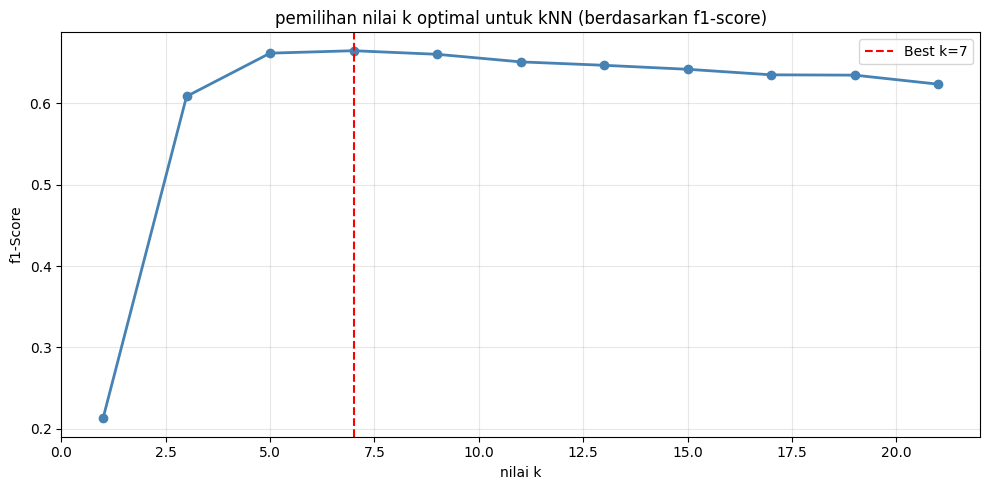

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_scores.keys()), list(k_scores.values()),
         marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("nilai k")
plt.ylabel("f1-Score")
plt.title("pemilihan nilai k optimal untuk kNN (berdasarkan f1-score)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/knn_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

latih model kNN

In [23]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean",
    n_jobs=-1
)
knn_model.fit(X_train_res, y_train_res)
y_pred_knn = knn_model.predict(X_test)

print("hasil evaluasi kNN")
print(classification_report(y_test, y_pred_knn,
                             target_names=["normal", "anomali"]))

hasil evaluasi kNN
              precision    recall  f1-score   support

      normal       1.00      0.96      0.98      7354
     anomali       0.52      0.93      0.66       318

    accuracy                           0.96      7672
   macro avg       0.76      0.95      0.82      7672
weighted avg       0.98      0.96      0.97      7672



In [24]:
knn_metrics = {
    "model"     : "kNN",
    "best_k"    : best_k,
    "threshold" : 0.5,
    "accuracy"  : round(accuracy_score(y_test,  y_pred_knn), 4),
    "precision" : round(precision_score(y_test, y_pred_knn, zero_division=0), 4),
    "recall"    : round(recall_score(y_test,    y_pred_knn, zero_division=0), 4),
    "f1_score"  : round(f1_score(y_test,        y_pred_knn, zero_division=0), 4),
}
print(knn_metrics)

{'model': 'kNN', 'best_k': 7, 'threshold': 0.5, 'accuracy': 0.961, 'precision': 0.5166, 'recall': 0.9308, 'f1_score': 0.6644}


confusion matrix kNN

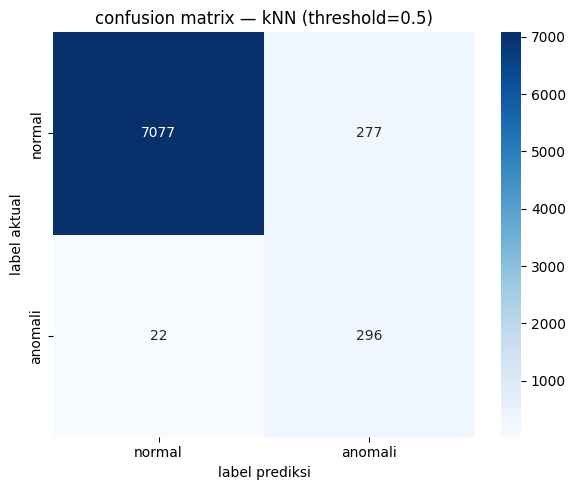

In [25]:
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "anomali"],
            yticklabels=["normal", "anomali"])
plt.title("confusion matrix — kNN (threshold=0.5)")
plt.ylabel("label aktual")
plt.xlabel("label prediksi")
plt.tight_layout()
plt.savefig("data/processed/cm_knn.png", dpi=150, bbox_inches="tight")
plt.show()

simpan model kNN

In [26]:
joblib.dump(knn_model, "data/models/knn_model.pkl")

['data/models/knn_model.pkl']

cari c optimal dan latih logistic regression

In [ ]:
C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
c_scores = {}

for C in C_values:
    lr_temp = LogisticRegression(
        C=C, max_iter=1000, random_state=42
    )
    lr_temp.fit(X_train_res, y_train_res)
    y_pred_temp = lr_temp.predict(X_test)
    score = f1_score(y_test, y_pred_temp, zero_division=0)
    c_scores[C] = round(score, 4)
    print(f"  C={C:5.2f} → f1_score={score:.4f}")

best_C = max(c_scores, key=c_scores.get)
print(f"\nnilai C terbaik: {best_C} (f1_score={c_scores[best_C]:.4f})")

  C= 0.01 → f1_score=0.4592
  C= 0.10 → f1_score=0.5738
  C= 0.50 → f1_score=0.5843
  C= 1.00 → f1_score=0.5860
  C= 5.00 → f1_score=0.6051
  C=10.00 → f1_score=0.6069

nilai C terbaik: 10.0 (f1_score=0.6069)


In [ ]:
lr_model = LogisticRegression(
    C=best_C,
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
lr_model.fit(X_train_res, y_train_res)
y_pred_lr = lr_model.predict(X_test)

print("hasil evaluasi logistic regression")
print(classification_report(y_test, y_pred_lr,
                             target_names=["normal", "anomali"]))

hasil evaluasi logistic regression
              precision    recall  f1-score   support

      normal       1.00      0.94      0.97      7354
     anomali       0.44      1.00      0.61       318

    accuracy                           0.95      7672
   macro avg       0.72      0.97      0.79      7672
weighted avg       0.98      0.95      0.96      7672



In [29]:
lr_metrics = {
    "model"     : "Logistic Regression",
    "best_C"    : best_C,
    "threshold" : 0.5,
    "accuracy"  : round(accuracy_score(y_test,  y_pred_lr), 4),
    "precision" : round(precision_score(y_test, y_pred_lr, zero_division=0), 4),
    "recall"    : round(recall_score(y_test,    y_pred_lr, zero_division=0), 4),
    "f1_score"  : round(f1_score(y_test,        y_pred_lr, zero_division=0), 4),
}
print(lr_metrics)

{'model': 'Logistic Regression', 'best_C': 10.0, 'threshold': 0.5, 'accuracy': 0.9463, 'precision': 0.4356, 'recall': 1.0, 'f1_score': 0.6069}


confusion matrix logistic regression

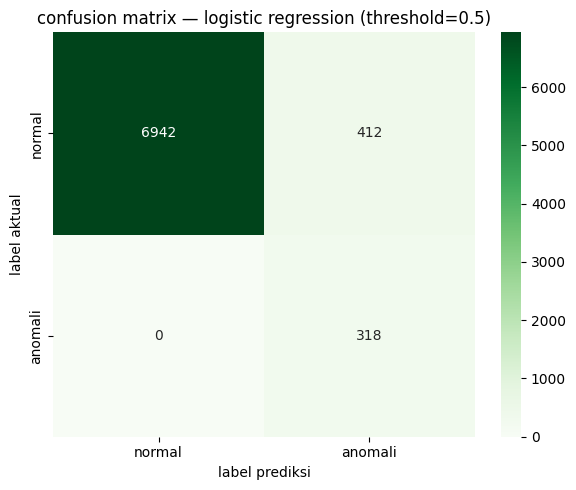

In [30]:
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["normal", "anomali"],
            yticklabels=["normal", "anomali"])
plt.title("confusion matrix — logistic regression (threshold=0.5)")
plt.ylabel("label aktual")
plt.xlabel("label prediksi")
plt.tight_layout()
plt.savefig("data/processed/cm_lr.png", dpi=150, bbox_inches="tight")
plt.show()

simpan model logistic regression

In [31]:
joblib.dump(lr_model, "data/models/lr_model.pkl")

['data/models/lr_model.pkl']

perbandingan kNN dan logistic regression

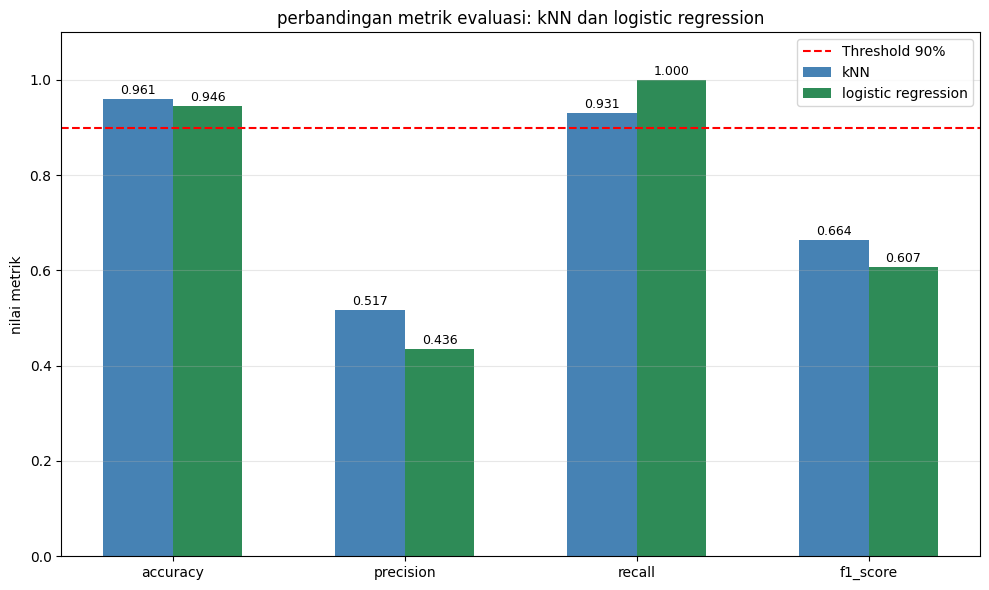

In [32]:
metrik_labels = ["accuracy", "precision", "recall", "f1_score"]
knn_vals = [knn_metrics[m] for m in metrik_labels]
lr_vals  = [lr_metrics[m]  for m in metrik_labels]

x = np.arange(len(metrik_labels))
width = 0.3

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, knn_vals, width, label="kNN", color="steelblue")
plt.bar(x + width/2, lr_vals,  width, label="logistic regression", color="seagreen")
plt.axhline(y=0.90, color="red", linestyle="--", linewidth=1.5, label="Threshold 90%")
plt.xticks(x, ["accuracy", "precision", "recall", "f1_score"])
plt.ylabel("nilai metrik")
plt.ylim(0, 1.1)
plt.title("perbandingan metrik evaluasi: kNN dan logistic regression")
plt.legend()
plt.grid(axis="y", alpha=0.3)
for i, (v1, v2) in enumerate(zip(knn_vals, lr_vals)):
    plt.text(i - width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    plt.text(i + width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/processed/perbandingan_model.png", dpi=150, bbox_inches="tight")
plt.show()

pengecekan apakah memenuhi threshold ≥ 90%

In [33]:
def cek_kelayakan(nama, metrics):
    print(f"\n  model: {nama}")
    lulus = True
    for m in ["accuracy", "precision", "recall", "f1_score"]:
        val = metrics[m]
        status = "lulus" if val >= 0.90 else "perlu perbaikan"
        print(f"    {m:10s}: {val:.4f} ({val*100:.2f}%) → {status}")
        if val < 0.90:
            lulus = False
    print(f"  Kesimpulan: {'model layak' if lulus else 'perlu tuning ulang'}")
    return lulus

knn_lulus = cek_kelayakan("kNN", knn_metrics)
lr_lulus  = cek_kelayakan("logistic regression", lr_metrics)


  model: kNN
    accuracy  : 0.9610 (96.10%) → lulus
    precision : 0.5166 (51.66%) → perlu perbaikan
    recall    : 0.9308 (93.08%) → lulus
    f1_score  : 0.6644 (66.44%) → perlu perbaikan
  Kesimpulan: perlu tuning ulang

  model: logistic regression
    accuracy  : 0.9463 (94.63%) → lulus
    precision : 0.4356 (43.56%) → perlu perbaikan
    recall    : 1.0000 (100.00%) → lulus
    f1_score  : 0.6069 (60.69%) → perlu perbaikan
  Kesimpulan: perlu tuning ulang


menyimpan semua matrik ke json

In [34]:
all_metrics = {
    "knn": knn_metrics,
    "logistic_regression": lr_metrics
}
with open("data/models/metrics_awal.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print(f"\nringkasan:")
print(f"  kNN (k={best_k}, threshold=0.5): "
      f"acc={knn_metrics['accuracy']}, f1={knn_metrics['f1_score']}")
print(f"  logistic regression (C={best_C}, threshold=0.5) : "
      f"acc={lr_metrics['accuracy']},  f1={lr_metrics['f1_score']}")


ringkasan:
  kNN (k=7, threshold=0.5): acc=0.961, f1=0.6644
  logistic regression (C=10.0, threshold=0.5) : acc=0.9463,  f1=0.6069
